---
<center>

  # **Tarea 03**

**Realizado Por:**

   Samuel Huertas Rojas

---
</center>

# 1.


Considere el problema de frontera
$$

\begin{cases}
u_{xx}(x,y) + u_{yy}(x,y) - u_x(x,y) = f(x,y), & (x,y)\in\Omega,\\[2mm]
u(x,y) = g(x,y), & (x,y)\in \partial\Omega.
\end{cases}

$$


Proponga un esquema de diferencias finitas para este problema que tenga orden de precisión (2,2). 
Escribir de manera explícita cuál es el sistema de ecuaciones lineales que se debe resolver. 

Aproximar la solución $u$ en $\Omega := [0,2]\times[0,3]$, tomando las funciones $f$ y $g$ tales que la solución sea 
$
u(t,x) = e^{-t/2} \sin\left(\frac{\pi}{2}x\right)\cos\left(2x - \frac{\pi}{3}\right).
$

# 2.

Sea $R := (0,\ell_x)\times(0,\ell_y)$. Considere los problemas de valores iniciales y de frontera:

$$

\boxed{\text{Px}}
\qquad
\left\{
\begin{aligned}
u_t(t,x,y) \;-\; \alpha\, u_{xx}(t,x,y) \;-\; \beta\, u_{yy}(t,x,y) \;+\; \xi\, u_y(t,x,y) &= f(t,x,y), 
& (x,y)\in R,\; t>0, \\[2mm]
u(0,x,y) &= u_0(x,y), 
& 0 \le x \le \ell_x,\ 0 \le y \le \ell_y,\\[2mm]
u(t,x,y) &= g(t,x,y), 
& t>0,\ (x,y)\in \partial R,\\[2mm]
u(t,\ell) + \beta\, u_x(t,\ell) &= g_2(t), 
& t>0.
\end{aligned}
\right.

$$


donde $\alpha, \beta \in \mathbb{R}$ y $f, u_0, g$ son funciones conocidas. Queremos aproximar la solución 
$u(t,x,y)$ para valores de $(x,y) \in \overline{R}$ y $t \in [0,T]$. 

Plantee el esquema de ADI–Crank–Nicolson para aproximar la solución $u$ de 
$\boxed{\text{Px}}$.  
Escribir de manera explícita cuál es el sistema de ecuaciones lineales que se debe resolver en cada paso.


  RESOLVEDOR DE ECUACIONES DIFERENCIALES ELÍPTICAS

Selecciona un ejemplo para ejecutar:
1. Ecuación de Poisson simple
2. Ecuación de reacción-difusión
3. Coeficiente de difusión variable
4. Ejemplo personalizado
0. Salir
Opción no válida

=== EJEMPLO 1: Ecuación de Poisson ===
Ecuación: -∇²u = sin(πx)sin(πy)
Frontera: u = 0

Ensamblando el sistema...
Resolviendo sistema de 1600 ecuaciones...
¡Sistema resuelto exitosamente!


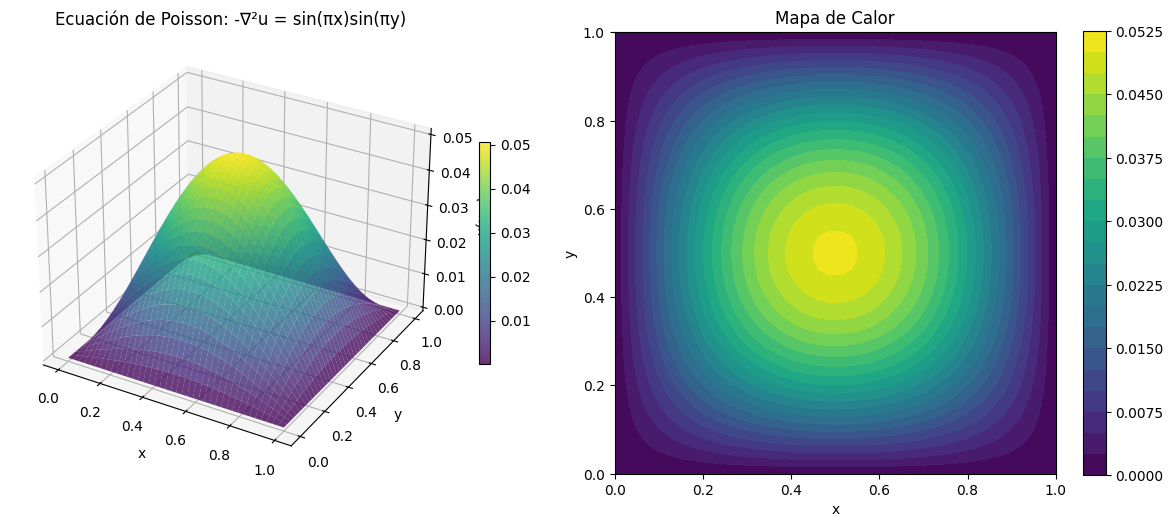


=== EJEMPLO 2: Reacción-Difusión ===
Ecuación: -∇²u + u = 1
Frontera: u = x² + y²

Ensamblando el sistema...
Resolviendo sistema de 1600 ecuaciones...
¡Sistema resuelto exitosamente!


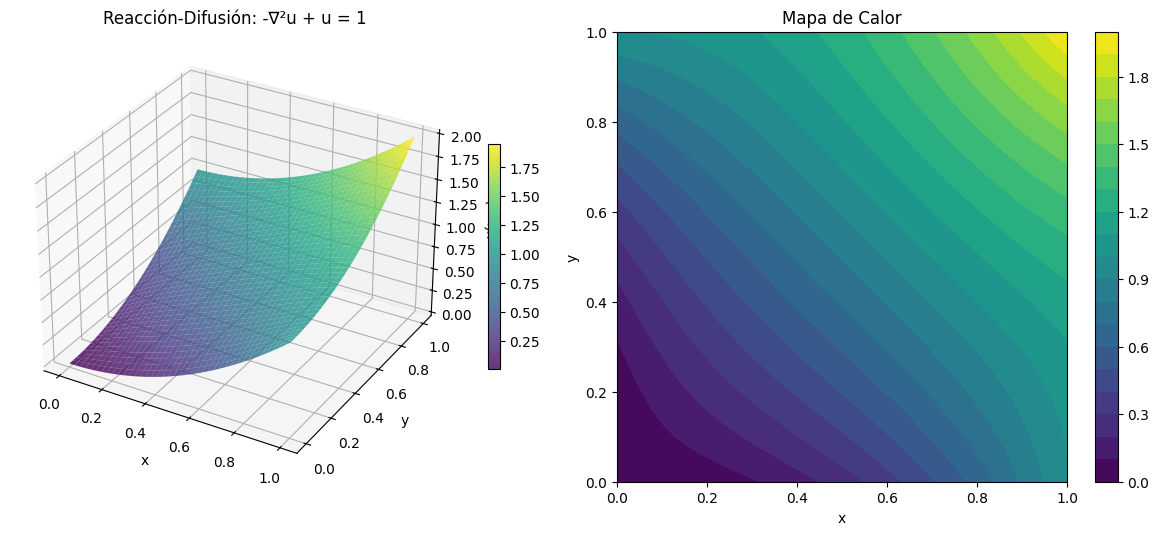


=== EJEMPLO 3: Difusión Variable ===
Ecuación: -∇·((1+x²)∇u) = 10
Frontera: u = 0

Ensamblando el sistema...
Resolviendo sistema de 1600 ecuaciones...
¡Sistema resuelto exitosamente!


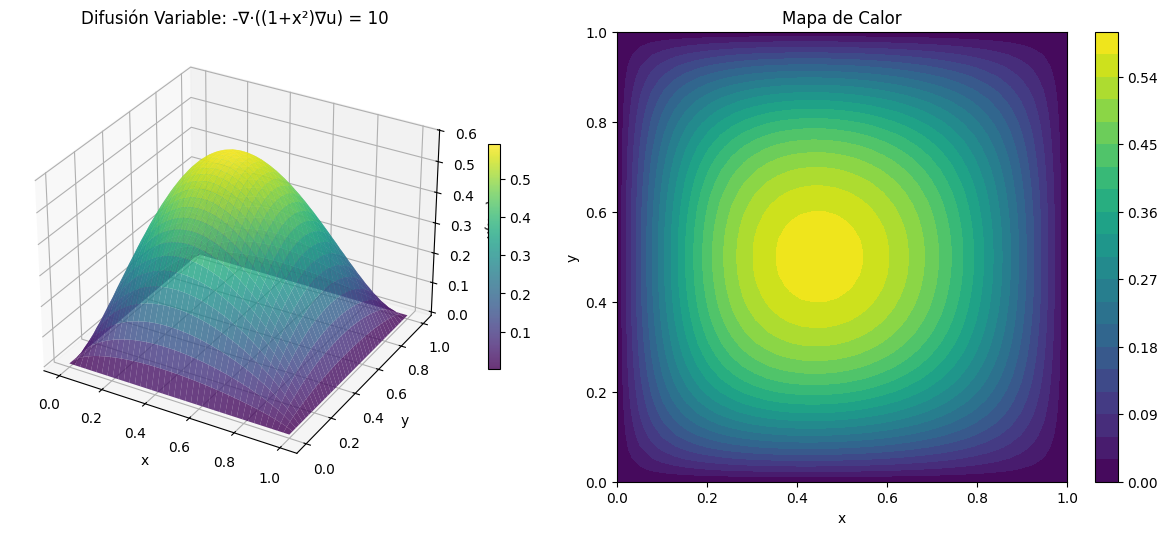

¡Hasta luego!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
from matplotlib import cm

class EllipticPDESolver:
    """
    Resolvedor de ecuaciones diferenciales elípticas en 2D
    Resuelve: -∇·(a∇u) + bu = f en el dominio [0,Lx]×[0,Ly]
    con condiciones de frontera de Dirichlet: u = g en la frontera
    """
    
    def __init__(self, Lx=1.0, Ly=1.0, nx=50, ny=50):
        """
        Inicializa el dominio y la malla
        
        Parámetros:
        -----------
        Lx, Ly : float
            Dimensiones del dominio rectangular
        nx, ny : int
            Número de puntos en dirección x e y
        """
        self.Lx = Lx
        self.Ly = Ly
        self.nx = nx
        self.ny = ny
        self.dx = Lx / (nx - 1)
        self.dy = Ly / (ny - 1)
        
        # Crear malla
        self.x = np.linspace(0, Lx, nx)
        self.y = np.linspace(0, Ly, ny)
        self.X, self.Y = np.meshgrid(self.x, self.y)
        
        self.n_nodes = nx * ny
        self.solution = None
        
    def set_coefficients(self, a_func, b_func, f_func):
        """
        Define los coeficientes de la ecuación
        
        Parámetros:
        -----------
        a_func : callable
            Función a(x, y) - coeficiente de difusión
        b_func : callable
            Función b(x, y) - coeficiente de reacción
        f_func : callable
            Función f(x, y) - término fuente
        """
        self.a_func = a_func
        self.b_func = b_func
        self.f_func = f_func
        
    def set_boundary_conditions(self, g_func):
        """
        Define las condiciones de frontera de Dirichlet
        
        Parámetros:
        -----------
        g_func : callable
            Función g(x, y) que especifica el valor en la frontera
        """
        self.g_func = g_func
        
    def node_index(self, i, j):
        """Convierte índices (i,j) a índice global del nodo"""
        return j * self.nx + i
    
    def is_boundary(self, i, j):
        """Verifica si un nodo está en la frontera"""
        return i == 0 or i == self.nx-1 or j == 0 or j == self.ny-1
    
    def assemble_system(self):
        """
        Ensambla la matriz del sistema y el vector del lado derecho
        usando diferencias finitas
        """
        A = lil_matrix((self.n_nodes, self.n_nodes))
        b = np.zeros(self.n_nodes)
        
        dx2 = self.dx ** 2
        dy2 = self.dy ** 2
        
        for j in range(self.ny):
            for i in range(self.nx):
                idx = self.node_index(i, j)
                x, y = self.x[i], self.y[j]
                
                if self.is_boundary(i, j):
                    # Condición de frontera de Dirichlet
                    A[idx, idx] = 1.0
                    b[idx] = self.g_func(x, y)
                else:
                    # Nodos internos - diferencias finitas
                    a_val = self.a_func(x, y)
                    b_val = self.b_func(x, y)
                    f_val = self.f_func(x, y)
                    
                    # Aproximación de -∇·(a∇u) con diferencias finitas
                    # d²u/dx²
                    A[idx, self.node_index(i-1, j)] = -a_val / dx2
                    A[idx, self.node_index(i+1, j)] = -a_val / dx2
                    
                    # d²u/dy²
                    A[idx, self.node_index(i, j-1)] = -a_val / dy2
                    A[idx, self.node_index(i, j+1)] = -a_val / dy2
                    
                    # Término central
                    A[idx, idx] = 2*a_val/dx2 + 2*a_val/dy2 + b_val
                    
                    # Lado derecho
                    b[idx] = f_val
        
        return A.tocsr(), b
    
    def solve(self):
        """Resuelve el sistema lineal"""
        print("Ensamblando el sistema...")
        A, b = self.assemble_system()
        
        print(f"Resolviendo sistema de {self.n_nodes} ecuaciones...")
        u = spsolve(A, b)
        
        # Reorganizar solución en malla 2D
        self.solution = u.reshape((self.ny, self.nx))
        print("¡Sistema resuelto exitosamente!")
        
        return self.solution
    
    def plot_solution(self, title="Solución de la EDP Elíptica"):
        """Grafica la solución"""
        if self.solution is None:
            print("Error: Primero debes resolver el sistema")
            return
        
        fig = plt.figure(figsize=(12, 5))
        
        # Gráfica de superficie
        ax1 = fig.add_subplot(121, projection='3d')
        surf = ax1.plot_surface(self.X, self.Y, self.solution, 
                                cmap=cm.viridis, alpha=0.8)
        ax1.set_xlabel('x')
        ax1.set_ylabel('y')
        ax1.set_zlabel('u(x,y)')
        ax1.set_title(title)
        fig.colorbar(surf, ax=ax1, shrink=0.5)
        
        # Mapa de calor
        ax2 = fig.add_subplot(122)
        contour = ax2.contourf(self.X, self.Y, self.solution, levels=20, cmap=cm.viridis)
        ax2.set_xlabel('x')
        ax2.set_ylabel('y')
        ax2.set_title('Mapa de Calor')
        ax2.set_aspect('equal')
        fig.colorbar(contour, ax=ax2)
        
        plt.tight_layout()
        plt.show()


# ==================== EJEMPLOS DE USO ====================

def ejemplo_1_poisson():
    """
    Ejemplo 1: Ecuación de Poisson
    -∇²u = f(x,y) con u=0 en la frontera
    """
    print("\n=== EJEMPLO 1: Ecuación de Poisson ===")
    print("Ecuación: -∇²u = sin(πx)sin(πy)")
    print("Frontera: u = 0\n")
    
    solver = EllipticPDESolver(Lx=1.0, Ly=1.0, nx=40, ny=40)
    
    # Coeficientes
    a = lambda x, y: 1.0  # Difusión uniforme
    b = lambda x, y: 0.0  # Sin término de reacción
    f = lambda x, y: np.sin(np.pi*x) * np.sin(np.pi*y)  # Término fuente
    
    # Condiciones de frontera
    g = lambda x, y: 0.0  # u = 0 en la frontera
    
    solver.set_coefficients(a, b, f)
    solver.set_boundary_conditions(g)
    solver.solve()
    solver.plot_solution("Ecuación de Poisson: -∇²u = sin(πx)sin(πy)")


def ejemplo_2_reaccion_difusion():
    """
    Ejemplo 2: Ecuación de reacción-difusión
    -∇²u + u = 1 con condiciones de frontera no homogéneas
    """
    print("\n=== EJEMPLO 2: Reacción-Difusión ===")
    print("Ecuación: -∇²u + u = 1")
    print("Frontera: u = x² + y²\n")
    
    solver = EllipticPDESolver(Lx=1.0, Ly=1.0, nx=40, ny=40)
    
    a = lambda x, y: 1.0
    b = lambda x, y: 1.0  # Término de reacción
    f = lambda x, y: 1.0  # Término fuente constante
    
    g = lambda x, y: x**2 + y**2  # Condiciones de frontera
    
    solver.set_coefficients(a, b, f)
    solver.set_boundary_conditions(g)
    solver.solve()
    solver.plot_solution("Reacción-Difusión: -∇²u + u = 1")


def ejemplo_3_difusion_variable():
    """
    Ejemplo 3: Coeficiente de difusión variable
    -∇·(a(x,y)∇u) = f con a(x,y) variable
    """
    print("\n=== EJEMPLO 3: Difusión Variable ===")
    print("Ecuación: -∇·((1+x²)∇u) = 10")
    print("Frontera: u = 0\n")
    
    solver = EllipticPDESolver(Lx=1.0, Ly=1.0, nx=40, ny=40)
    
    a = lambda x, y: 1.0 + x**2  # Difusión variable
    b = lambda x, y: 0.0
    f = lambda x, y: 10.0
    
    g = lambda x, y: 0.0
    
    solver.set_coefficients(a, b, f)
    solver.set_boundary_conditions(g)
    solver.solve()
    solver.plot_solution("Difusión Variable: -∇·((1+x²)∇u) = 10")


def ejemplo_personalizado():
    """
    Plantilla para crear tu propio ejemplo
    """
    print("\n=== EJEMPLO PERSONALIZADO ===")
    
    # Configura tu dominio y resolución
    solver = EllipticPDESolver(Lx=2.0, Ly=2.0, nx=50, ny=50)
    
    # Define tus coeficientes (puedes modificarlos)
    a = lambda x, y: 1.0  # Coeficiente de difusión
    b = lambda x, y: 0.5  # Coeficiente de reacción
    f = lambda x, y: np.exp(-((x-1)**2 + (y-1)**2)/0.2)  # Término fuente
    
    # Define condiciones de frontera
    g = lambda x, y: 0.0  # Valores en la frontera
    
    solver.set_coefficients(a, b, f)
    solver.set_boundary_conditions(g)
    solver.solve()
    solver.plot_solution("Ecuación Personalizada")


# ==================== MENÚ PRINCIPAL ====================

if __name__ == "__main__":
    print("=" * 60)
    print("  RESOLVEDOR DE ECUACIONES DIFERENCIALES ELÍPTICAS")
    print("=" * 60)
    print("\nSelecciona un ejemplo para ejecutar:")
    print("1. Ecuación de Poisson simple")
    print("2. Ecuación de reacción-difusión")
    print("3. Coeficiente de difusión variable")
    print("4. Ejemplo personalizado")
    print("0. Salir")
    
    while True:
        try:
            opcion = input("\nOpción: ").strip()
            
            if opcion == "1":
                ejemplo_1_poisson()
            elif opcion == "2":
                ejemplo_2_reaccion_difusion()
            elif opcion == "3":
                ejemplo_3_difusion_variable()
            elif opcion == "4":
                ejemplo_personalizado()
            elif opcion == "0":
                print("¡Hasta luego!")
                break
            else:
                print("Opción no válida")
        except KeyboardInterrupt:
            print("\n¡Hasta luego!")
            break
        except Exception as e:
            print(f"Error: {e}")

# 3.

Demuestre que $\left( H^{2}(\Omega), (v,w)_{2,\Omega} \right)$ es un espacio de Hilbert, 
siendo $\Omega := (a,b)\subseteq \mathbb{R}$.

# 4.

Sea $u(x)=x^{\alpha}$, con $\alpha \in \mathbb{R}$, y consideremos $\Omega := (0,1)$.  
¿Para qué valores de $\alpha$ se garantiza que $u \in L^{2}(\Omega)$?  
¿Para cuáles se tiene $u \in H^{1}(\Omega)$?

# 5.

Considere el problema con valores en la frontera

$$

\left\{
\begin{aligned}
- u''(x) + q(x)\,u'(x) + r(x)\,u(x) &= f(x), \qquad x \in \Omega := (a,b), \\[2mm]
u(a) &= 0, \\[1mm]
u(b) &= 0,
\end{aligned}
\right.

$$

con $f \in L^{2}(\Omega)$, $q \in C^{1}(\overline{\Omega})$, $r \in C(\overline{\Omega})$ donde $q$ y $r$ verifican $
r - \tfrac{1}{2} q' \ge 0 \quad \text{en } \Omega.
$

* Plantee la formulación variacional asociada al problema.

* Demuestre que la formulación variacional tiene solución única.

Ayuda: Demuestre que  

$$

\int_{\Omega} q\, v\, v' = -\tfrac{1}{2} \int_{\Omega} q'\, v^{2}
\quad \text{para toda } v \in H^{1}_{0}(\Omega)

$$

(emplee un argumento de densidad y el hecho de que   $(\psi^{2})' = 2\psi \psi'$, $\forall\, \psi \in C^{\infty}_{0}(\Omega)$).